<h1 style="color:#56B4E9;">Week 8 — Day 5</h1>

<h2 style="color:#0072B2;">Full Evaluation, Explainability & Sprint Review</h2>

### Oxford-IIIT Pet — Explainable 37-Breed Classification

Day 5 continues the integrated image-classification system created on Day 4.

The trained model will not be retrained. Instead, it will be loaded from the exported
artifacts and examined through complete evaluation, baseline comparison, error
analysis, and SHAP explanations.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Evaluate the classifier using task-appropriate metrics.
- Compare the trained model with a valid baseline for the same task.
- Explain why SMOTE is not appropriate for this balanced image dataset.
- Study the precision-recall trade-off for individual breeds.
- Generate global and per-image explanations using SHAP.
- Communicate the results to non-technical stakeholders.
- Complete the Sprint Review and Retrospective.

<h2 style="color:#0072B2;">5.1 Loading the Day 4 Integrated Model</h2>

Day 4 exported three connected artifacts:

- The trained MobileNetV2 classifier.
- The exact order of the 37 output classes.
- The preprocessing contract expected by the model.

Loading these artifacts preserves training/serving consistency and avoids unnecessary
retraining.

The Week 6 ECG model cannot be used as a numerical baseline because it solved a
different task with different inputs and labels. Therefore, this notebook will use
a majority-class baseline built from the same pet dataset.

In [1]:
%pip install -q shap opencv-python scikit-learn seaborn

from pathlib import Path
import json
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
)
from tensorflow.keras.utils import get_file

RANDOM_STATE = 42
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DAY4_OUTPUT_DIRECTORY = Path(
    "../day4/outputs/week8_day4"
).resolve()

MODEL_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "pet_breed_classifier.keras"
)

CLASS_NAMES_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "class_names.json"
)

PREPROCESSING_PATH = (
    DAY4_OUTPUT_DIRECTORY /
    "preprocessing_config.json"
)

assert MODEL_PATH.exists(), (
    f"Model was not found: {MODEL_PATH}"
)
assert CLASS_NAMES_PATH.exists()
assert PREPROCESSING_PATH.exists()

pet_breed_model = tf.keras.models.load_model(
    MODEL_PATH
)

with open(
    CLASS_NAMES_PATH,
    encoding="utf-8",
) as class_file:
    class_names = json.load(class_file)

with open(
    PREPROCESSING_PATH,
    encoding="utf-8",
) as configuration_file:
    preprocessing_config = json.load(
        configuration_file
    )

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)
print("Loaded model:", MODEL_PATH)
print("Number of classes:", len(class_names))
print("Expected image size:", TARGET_SIZE)
print(
    "Normalization:",
    preprocessing_config["normalization"],
)

Note: you may need to restart the kernel to use updated packages.


I0000 00:00:1789025565.045135  262574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789025565.048702  262574 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789025566.790105  262574 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789025568.576733  262574 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow: 2.21.0
SHAP: 0.52.0
Loaded model: /home/haitham/binx-ai-ml-internship/week8/day4/outputs/week8_day4/pet_breed_classifier.keras
Number of classes: 37
Expected image size: (224, 224)
Normalization: MobileNetV2 preprocess_input


<h2 style="color:#0072B2;">5.2 Reconstructing the Evaluation Dataset</h2>

The dataset is reconstructed using the same class ordering, random state, and
stratified splitting method used during Day 4.

This guarantees that the final evaluation uses exactly the same unseen test images
without mixing training and test data.

In [2]:
search_directories = [
    Path("../day3/data").resolve(),
    Path("data").resolve(),
    Path("/tmp/.keras"),
    Path.home() / ".keras",
]

image_paths = []

for search_directory in search_directories:
    if not search_directory.exists():
        continue

    discovered_paths = sorted(
        search_directory.rglob("*.jpg")
    )

    if len(discovered_paths) >= 7390:
        image_paths = discovered_paths
        break

if not image_paths:
    archive_path = Path(
        get_file(
            fname="images.tar.gz",
            origin=(
                "https://www.robots.ox.ac.uk/~vgg/"
                "data/pets/data/images.tar.gz"
            ),
            extract=True,
        )
    )

    search_root = (
        archive_path
        if archive_path.is_dir()
        else archive_path.parent
    )

    image_paths = sorted(
        search_root.rglob("*.jpg")
    )

assert len(image_paths) == 7390, (
    f"Expected 7,390 images, found {len(image_paths)}"
)

IMAGE_DIRECTORY = image_paths[0].parent

print("Image directory:", IMAGE_DIRECTORY)
print("Number of images:", len(image_paths))

Image directory: /tmp/.keras/oxford_iiit_pet/images_extracted/images
Number of images: 7390


In [3]:
image_metadata = pd.DataFrame({
    "image_path": [
        str(path)
        for path in image_paths
    ],
    "filename": [
        path.name
        for path in image_paths
    ],
    "breed": [
        path.stem.rsplit("_", 1)[0]
        for path in image_paths
    ],
})

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

image_metadata["label"] = (
    image_metadata["breed"]
    .map(class_to_index)
)

assert image_metadata["label"].notna().all()

train_metadata, temporary_metadata = train_test_split(
    image_metadata,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=image_metadata["label"],
)

validation_metadata, test_metadata = train_test_split(
    temporary_metadata,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_metadata["label"],
)

train_metadata = train_metadata.reset_index(drop=True)
validation_metadata = validation_metadata.reset_index(drop=True)
test_metadata = test_metadata.reset_index(drop=True)

split_summary = pd.DataFrame([
    {
        "split": "Training",
        "images": len(train_metadata),
    },
    {
        "split": "Validation",
        "images": len(validation_metadata),
    },
    {
        "split": "Test",
        "images": len(test_metadata),
    },
])

display(split_summary)

,split,images
0,Training,5173
1,Validation,1108
2,Test,1109


<h2 style="color:#0072B2;">5.3 Class Balance and the SMOTE Decision</h2>

SMOTE is useful when tabular training data contains a strongly underrepresented
class. It creates synthetic feature vectors between minority examples.

Directly interpolating image pixels can create unrealistic images that do not
represent valid animals. Image augmentation is therefore more appropriate for this
computer-vision task.

The imbalance ratio is calculated as:

$$
\text{Imbalance Ratio}
=
\frac{\text{Largest Class Size}}
{\text{Smallest Class Size}}
$$

A ratio close to 1 indicates that the dataset is already balanced.

,minimum_class_size,maximum_class_size,imbalance_ratio,smote_required,selected_solution
0,134,140,1.0448,False,Image augmentation used instead


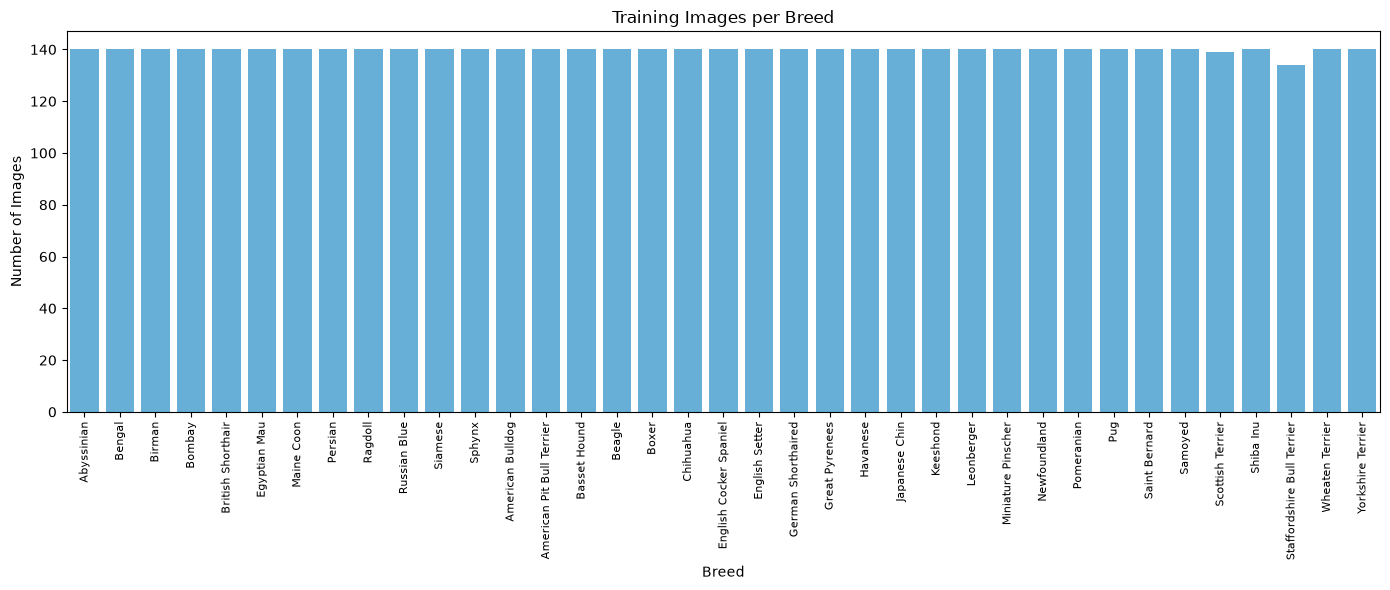

In [4]:
training_distribution = (
    train_metadata["breed"]
    .value_counts()
    .reindex(class_names)
)

largest_class_size = training_distribution.max()
smallest_class_size = training_distribution.min()

imbalance_ratio = (
    largest_class_size /
    smallest_class_size
)

balance_summary = pd.DataFrame({
    "minimum_class_size": [smallest_class_size],
    "maximum_class_size": [largest_class_size],
    "imbalance_ratio": [imbalance_ratio],
    "smote_required": [False],
    "selected_solution": [
        "Image augmentation used instead"
    ],
})

display(balance_summary.round(4))

plt.figure(figsize=(14, 6))

sns.barplot(
    x=[
        name.replace("_", " ").title()
        for name in training_distribution.index
    ],
    y=training_distribution.values,
    color="#56B4E9",
)

plt.title("Training Images per Breed")
plt.xlabel("Breed")
plt.ylabel("Number of Images")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">5.4 Rebuilding the Prediction Pipeline</h2>

A fair evaluation must use exactly the same preprocessing contract used during
training.

The test pipeline therefore performs BGR-to-RGB conversion, aspect-ratio-preserving
resizing, padding, and MobileNetV2 normalization before sending each image to the
loaded classifier.

In [5]:
def resize_with_padding(
    image,
    target_size=(224, 224),
    padding_color=(0, 0, 0),
):
    target_width, target_height = target_size
    original_height, original_width = image.shape[:2]

    scale = min(
        target_width / original_width,
        target_height / original_height,
    )

    new_width = int(
        round(original_width * scale)
    )
    new_height = int(
        round(original_height * scale)
    )

    interpolation = (
        cv2.INTER_AREA
        if scale < 1
        else cv2.INTER_CUBIC
    )

    resized_image = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation,
    )

    remaining_width = target_width - new_width
    remaining_height = target_height - new_height

    left = remaining_width // 2
    right = remaining_width - left
    top = remaining_height // 2
    bottom = remaining_height - top

    return cv2.copyMakeBorder(
        resized_image,
        top,
        bottom,
        left,
        right,
        borderType=cv2.BORDER_CONSTANT,
        value=padding_color,
    )


def preprocess_pet_image(image_path):
    bgr_image = cv2.imread(
        str(image_path)
    )

    if bgr_image is None:
        raise ValueError(
            f"OpenCV could not read: {image_path}"
        )

    rgb_image = cv2.cvtColor(
        bgr_image,
        cv2.COLOR_BGR2RGB,
    )

    resized_image = resize_with_padding(
        rgb_image,
        target_size=TARGET_SIZE,
    )

    return preprocess_input(
        resized_image.astype(np.float32)
    )


def load_test_image(path_value, label_value):
    raw_path = (
        path_value.item()
        if hasattr(path_value, "item")
        else path_value
    )

    if isinstance(raw_path, bytes):
        raw_path = raw_path.decode("utf-8")

    image = preprocess_pet_image(raw_path)

    return image, np.int32(label_value)


def tensorflow_test_preprocessing(
    image_path,
    label,
):
    image, label = tf.numpy_function(
        load_test_image,
        [image_path, label],
        [tf.float32, tf.int32],
    )

    image.set_shape((224, 224, 3))
    label.set_shape(())

    return image, label


test_dataset = (
    tf.data.Dataset
    .from_tensor_slices((
        test_metadata["image_path"].to_numpy(),
        test_metadata["label"].to_numpy(
            dtype=np.int32
        ),
    ))
    .map(
        tensorflow_test_preprocessing,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

sample_images, sample_labels = next(
    iter(test_dataset)
)

print("Test batches:", len(test_dataset))
print("Batch shape:", sample_images.shape)
print(
    "Pixel range:",
    (
        float(tf.reduce_min(sample_images)),
        float(tf.reduce_max(sample_images)),
    ),
)

Test batches: 35
Batch shape: (32, 224, 224, 3)
Pixel range: (-1.0, 1.0)


<h2 style="color:#0072B2;">5.5 Task-Appropriate Evaluation</h2>

Because this is a balanced multiclass problem, accuracy is useful but is not reported
alone.

The following metrics are calculated:

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

$$
F_1
=
2
\frac{\text{Precision}\times\text{Recall}}
{\text{Precision}+\text{Recall}}
$$

Macro averaging gives every breed equal importance, while weighted averaging accounts
for the number of images in each breed.

Multiclass ROC-AUC is calculated using One-vs-Rest, where each breed is temporarily
compared against all other breeds.

In [6]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    top_k_accuracy_score,
)
from sklearn.preprocessing import label_binarize

DAY5_OUTPUT_DIRECTORY = Path(
    "outputs/week8_day5"
)

DAY5_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

true_labels = test_metadata[
    "label"
].to_numpy(dtype=np.int32)

model_probabilities = (
    pet_breed_model.predict(
        test_dataset,
        verbose=1,
    )
)

model_predictions = np.argmax(
    model_probabilities,
    axis=1,
)

assert model_probabilities.shape == (
    len(test_metadata),
    len(class_names),
)

print("Predictions:", len(model_predictions))
print(
    "Probability sums:",
    np.round(
        model_probabilities[:5].sum(axis=1),
        5,
    ),
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 543ms/step
Predictions: 1109
Probability sums: [1. 1. 1. 1. 1.]


<h2 style="color:#0072B2;">5.6 Comparison Against a Valid Baseline</h2>

The baseline predicts using only the class frequencies found in the training data.
It does not inspect image pixels.

This creates a fair minimum reference for the same 37-class task.

A useful model should strongly outperform this baseline across accuracy, F1,
Top-3 accuracy, ROC-AUC, and Precision-Recall AUC.

In [7]:
number_of_classes = len(class_names)

class_prior_probabilities = (
    training_distribution
    .to_numpy(dtype=np.float64)
)

class_prior_probabilities /= (
    class_prior_probabilities.sum()
)

baseline_probabilities = np.tile(
    class_prior_probabilities,
    (len(true_labels), 1),
)

baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1,
)

binarized_true_labels = label_binarize(
    true_labels,
    classes=np.arange(number_of_classes),
)


def calculate_complete_metrics(
    model_name,
    probabilities,
):
    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            average="macro",
            zero_division=0,
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            true_labels,
            predictions,
            average="weighted",
            zero_division=0,
        )
    )

    return {
        "model": model_name,
        "accuracy": accuracy_score(
            true_labels,
            predictions,
        ),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top_3_accuracy": top_k_accuracy_score(
            true_labels,
            probabilities,
            k=3,
            labels=np.arange(number_of_classes),
        ),
        "roc_auc_macro_ovr": roc_auc_score(
            true_labels,
            probabilities,
            average="macro",
            multi_class="ovr",
            labels=np.arange(number_of_classes),
        ),
        "pr_auc_macro": average_precision_score(
            binarized_true_labels,
            probabilities,
            average="macro",
        ),
    }


complete_evaluation = pd.DataFrame([
    calculate_complete_metrics(
        "Class-Prior Baseline",
        baseline_probabilities,
    ),
    calculate_complete_metrics(
        "MobileNetV2 Classifier",
        model_probabilities,
    ),
])

display(
    complete_evaluation.round(4)
)

complete_evaluation.to_csv(
    DAY5_OUTPUT_DIRECTORY /
    "baseline_comparison.csv",
    index=False,
)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,roc_auc_macro_ovr,pr_auc_macro
0,Class-Prior Baseline,0.0271,0.0007,0.0270,0.0014,0.0014,0.0812,0.5000,0.0270
1,MobileNetV2 Classifier,0.8900,0.8976,0.8898,0.8896,0.8899,0.9838,0.9978,0.9533


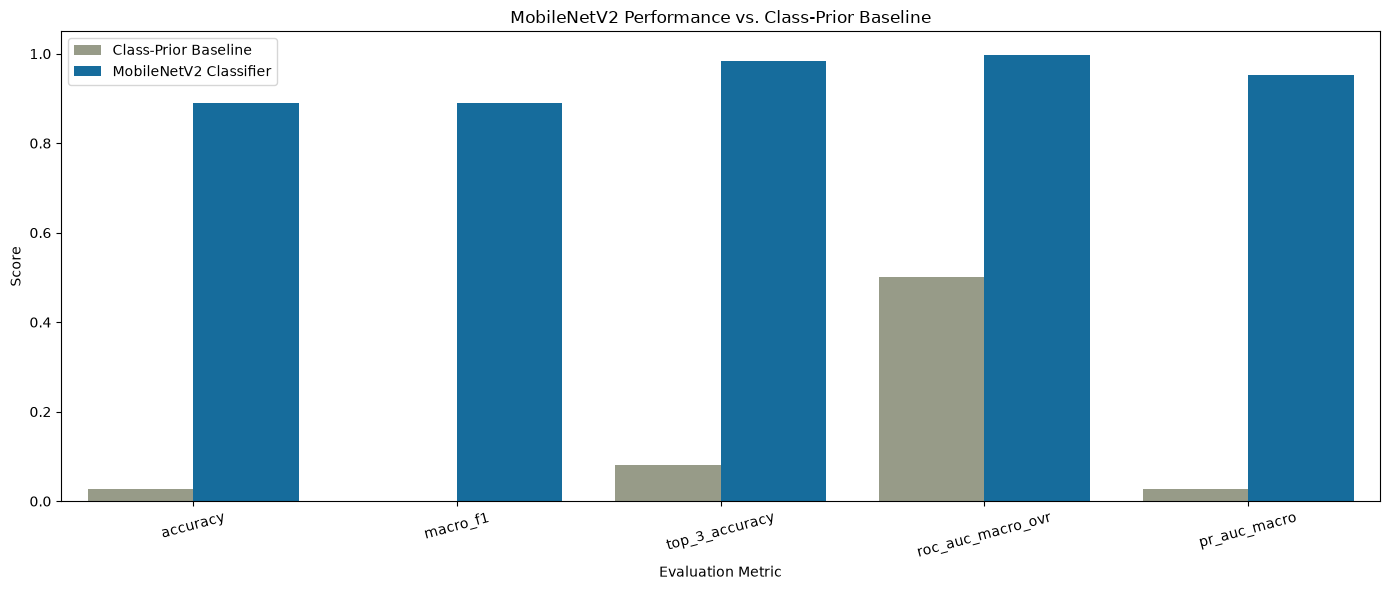

In [8]:
comparison_metrics = [
    "accuracy",
    "macro_f1",
    "top_3_accuracy",
    "roc_auc_macro_ovr",
    "pr_auc_macro",
]

comparison_plot_data = (
    complete_evaluation[
        ["model", *comparison_metrics]
    ]
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score",
    )
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_plot_data,
    x="metric",
    y="score",
    hue="model",
    palette=["#999E85", "#0072B2"],
)

plt.ylim(0, 1.05)
plt.title(
    "MobileNetV2 Performance vs. Class-Prior Baseline"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "baseline_comparison.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

<h2 style="color:#0072B2;">5.7 Evaluation Findings</h2>

The MobileNetV2 classifier strongly outperformed the class-prior baseline.

| Metric | Baseline | MobileNetV2 |
|---|---:|---:|
| Accuracy | 2.71% | 89.00% |
| Macro F1 | 0.14% | 88.96% |
| Top-3 Accuracy | 8.12% | 98.38% |
| Macro ROC-AUC | 50.00% | 99.78% |
| Macro PR-AUC | 2.70% | 95.33% |

ROC-AUC shows that the model can separate each breed from the remaining breeds.

PR-AUC is especially informative because it measures whether the model can retrieve
images from a specific breed without producing many false-positive predictions.

<h2 style="color:#0072B2;">5.8 Per-Breed Precision–Recall Analysis</h2>

Global metrics can hide weak individual classes. Therefore, precision, recall,
F1-score, and Average Precision are calculated independently for all 37 breeds.

A low recall means that many real images from a breed were missed.

A low precision means that images from other breeds were incorrectly assigned to
that breed.

The Precision–Recall curve shows how this trade-off changes at different probability
thresholds. The current multiclass system uses the class with the highest probability,
so no single binary threshold is applied during normal classification.

In [9]:
from sklearn.metrics import precision_recall_curve

class_precision, class_recall, class_f1, class_support = (
    precision_recall_fscore_support(
        true_labels,
        model_predictions,
        labels=np.arange(number_of_classes),
        zero_division=0,
    )
)

class_average_precision = []

for class_index in range(number_of_classes):
    binary_true_labels = (
        true_labels == class_index
    ).astype(np.int32)

    class_average_precision.append(
        average_precision_score(
            binary_true_labels,
            model_probabilities[:, class_index],
        )
    )

per_breed_metrics = pd.DataFrame({
    "class_index": np.arange(number_of_classes),
    "breed": [
        name.replace("_", " ").title()
        for name in class_names
    ],
    "precision": class_precision,
    "recall": class_recall,
    "f1_score": class_f1,
    "average_precision": class_average_precision,
    "support": class_support,
})

per_breed_metrics = (
    per_breed_metrics
    .sort_values(
        "f1_score",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("Five weakest breeds by F1-score:")
display(
    per_breed_metrics.head(5).round(4)
)

print("Five strongest breeds by F1-score:")
display(
    per_breed_metrics.tail(5)
    .sort_values(
        "f1_score",
        ascending=False,
    )
    .round(4)
)

per_breed_metrics.to_csv(
    DAY5_OUTPUT_DIRECTORY /
    "per_breed_metrics.csv",
    index=False,
)

Five weakest breeds by F1-score:


,class_index,breed,precision,recall,f1_score,average_precision,support
0,34,Staffordshire Bull Terrier,0.5758,0.6552,0.6129,0.7045,29
1,13,American Pit Bull Terrier,0.7273,0.5333,0.6154,0.7743,30
2,8,Ragdoll,0.6765,0.7667,0.7188,0.8149,30
3,1,Bengal,1.0000,0.5667,0.7234,0.9508,30
4,9,Russian Blue,0.7353,0.8333,0.7812,0.8799,30


Five strongest breeds by F1-score:


,class_index,breed,precision,recall,f1_score,average_precision,support
36,32,Scottish Terrier,1.0000,1.0000,1.0000,1.0000,30
35,35,Wheaten Terrier,1.0000,0.9667,0.9831,1.0000,30
34,27,Newfoundland,0.9375,1.0000,0.9677,0.9784,30
32,36,Yorkshire Terrier,0.9667,0.9667,0.9667,0.9978,30
33,29,Pug,0.9667,0.9667,0.9667,0.9968,30


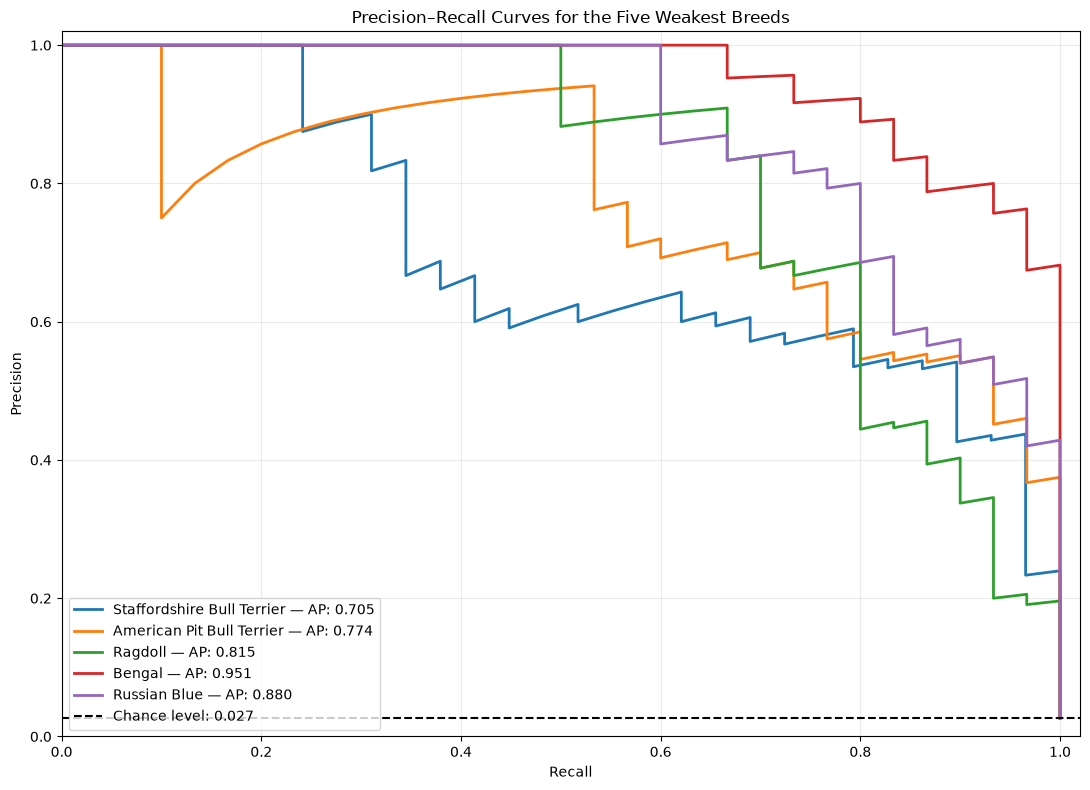

In [10]:
weakest_breed_indices = (
    per_breed_metrics
    .head(5)["class_index"]
    .to_numpy(dtype=np.int32)
)

plt.figure(figsize=(11, 8))

for class_index in weakest_breed_indices:
    binary_true_labels = (
        true_labels == class_index
    ).astype(np.int32)

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            binary_true_labels,
            model_probabilities[:, class_index],
        )
    )

    breed_name = (
        class_names[class_index]
        .replace("_", " ")
        .title()
    )

    breed_ap = average_precision_score(
        binary_true_labels,
        model_probabilities[:, class_index],
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{breed_name} — AP: {breed_ap:.3f}",
    )

class_prevalence = 1 / number_of_classes

plt.axhline(
    class_prevalence,
    color="black",
    linestyle="--",
    label=f"Chance level: {class_prevalence:.3f}",
)

plt.title(
    "Precision–Recall Curves for the Five Weakest Breeds"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "weakest_breeds_precision_recall.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

<h2 style="color:#0072B2;">5.9 Explainability with SHAP</h2>

SHAP explains a prediction by measuring how much each image region changes the
model output compared with a reference prediction.

The Shapley value for feature \(i\) is:

$$
\phi_i =
\sum_{S \subseteq F \setminus \{i\}}
\frac{|S|!(|F|-|S|-1)!}{|F|!}
\left[
f(S \cup \{i\})-f(S)
\right]
$$

For images, individual pixels are grouped into hierarchical regions.

- Positive SHAP values push the prediction toward the selected breed.
- Negative SHAP values push the prediction away from that breed.
- Values near zero indicate regions with little influence.

A blurred image masker is used to hide regions without replacing them with
unrealistic random pixels.

True breed: Sphynx
Predicted breed: Sphynx
Confidence: 97.95%


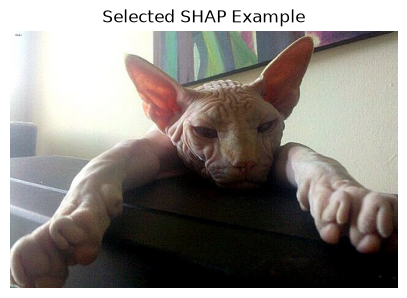

In [11]:
prediction_confidence = np.max(
    model_probabilities,
    axis=1,
)

correct_prediction_mask = (
    model_predictions == true_labels
)

candidate_positions = np.where(
    correct_prediction_mask
    & (prediction_confidence >= 0.90)
)[0]

assert len(candidate_positions) > 0

local_example_position = int(
    candidate_positions[0]
)

local_example_path = test_metadata.loc[
    local_example_position,
    "image_path",
]

local_true_index = int(
    true_labels[local_example_position]
)

local_predicted_index = int(
    model_predictions[local_example_position]
)

local_model_image = np.expand_dims(
    preprocess_pet_image(local_example_path),
    axis=0,
)

local_display_image = cv2.cvtColor(
    cv2.imread(local_example_path),
    cv2.COLOR_BGR2RGB,
)

print(
    "True breed:",
    class_names[local_true_index]
    .replace("_", " ")
    .title(),
)
print(
    "Predicted breed:",
    class_names[local_predicted_index]
    .replace("_", " ")
    .title(),
)
print(
    "Confidence:",
    f"{prediction_confidence[local_example_position]:.2%}",
)

plt.figure(figsize=(5, 5))
plt.imshow(local_display_image)
plt.title("Selected SHAP Example")
plt.axis("off")
plt.show()

In [12]:
display_class_names = [
    name.replace("_", " ").title()
    for name in class_names
]


def shap_prediction_function(image_batch):
    image_batch = np.asarray(
        image_batch,
        dtype=np.float32,
    )

    return pet_breed_model.predict(
        image_batch,
        verbose=0,
    )


image_masker = shap.maskers.Image(
    "blur(32,32)",
    local_model_image.shape[1:],
)

image_explainer = shap.Explainer(
    shap_prediction_function,
    image_masker,
    output_names=display_class_names,
    algorithm="partition",
)

print(
    "Calculating the local SHAP explanation..."
)

local_shap_values = image_explainer(
    local_model_image,
    max_evals=100,
    batch_size=10,
    outputs=shap.Explanation.argsort.flip[:1],
)

print(
    "SHAP values shape:",
    local_shap_values.values.shape,
)
print("Local explanation completed.")

Calculating the local SHAP explanation...


  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.23s/it]               

SHAP values shape: (1, 224, 224, 3, 1)
Local explanation completed.


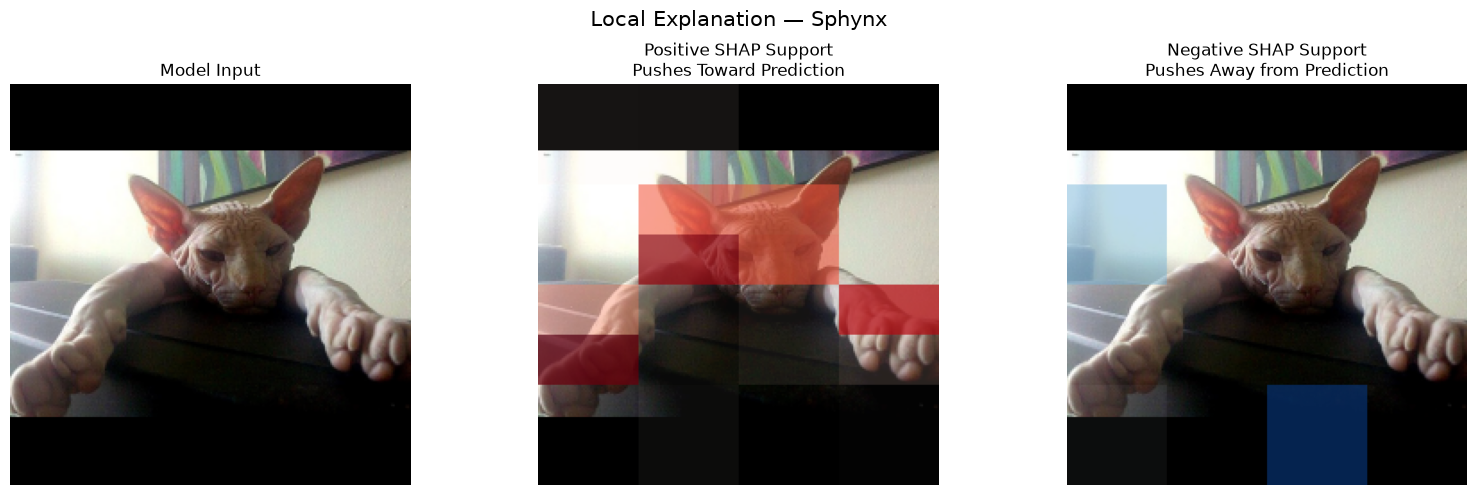

In [13]:
local_values = (
    local_shap_values.values[0]
)

if local_values.ndim == 4:
    local_values = local_values[..., 0]

signed_region_importance = (
    local_values.sum(axis=-1)
)

positive_support = np.maximum(
    signed_region_importance,
    0,
)

negative_support = np.maximum(
    -signed_region_importance,
    0,
)

positive_limit = max(
    np.percentile(positive_support, 99),
    1e-8,
)

negative_limit = max(
    np.percentile(negative_support, 99),
    1e-8,
)

model_ready_display = np.clip(
    (local_model_image[0] + 1.0) / 2.0,
    0,
    1,
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(model_ready_display)
axes[0].set_title("Model Input")
axes[0].axis("off")

axes[1].imshow(model_ready_display)
axes[1].imshow(
    positive_support,
    cmap="Reds",
    alpha=np.clip(
        positive_support / positive_limit,
        0,
        0.75,
    ),
)
axes[1].set_title(
    "Positive SHAP Support\nPushes Toward Prediction"
)
axes[1].axis("off")

axes[2].imshow(model_ready_display)
axes[2].imshow(
    negative_support,
    cmap="Blues",
    alpha=np.clip(
        negative_support / negative_limit,
        0,
        0.75,
    ),
)
axes[2].set_title(
    "Negative SHAP Support\nPushes Away from Prediction"
)
axes[2].axis("off")

plt.suptitle(
    "Local Explanation — "
    + display_class_names[local_predicted_index],
    fontsize=15,
)
plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "local_shap_explanation.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

<h3 style="color:#009E73;">Local SHAP Interpretation</h3>

The selected Sphynx image was classified correctly with 97.95% confidence.

The strongest positive SHAP regions appeared around the large ears, wrinkled face,
skin, and front limbs. These are meaningful visual characteristics of the Sphynx
breed.

Most negative support appeared in background and padded regions. This indicates that
the prediction depended mainly on the animal rather than irrelevant surroundings.

<h2 style="color:#0072B2;">5.10 Explaining a Wrong Prediction</h2>

A high-confidence incorrect prediction is more informative than a random error.

It shows which image regions strongly supported the wrong breed and helps determine
whether the failure came from poor image quality, visual similarity, or a model
weakness.

True breed: Havanese
Wrong prediction: Newfoundland
Confidence: 99.05%


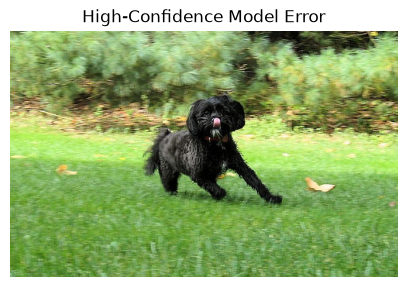

In [14]:
incorrect_positions = np.where(
    model_predictions != true_labels
)[0]

wrong_example_position = int(
    incorrect_positions[
        np.argmax(
            prediction_confidence[
                incorrect_positions
            ]
        )
    ]
)

wrong_example_path = test_metadata.loc[
    wrong_example_position,
    "image_path",
]

wrong_true_index = int(
    true_labels[wrong_example_position]
)

wrong_predicted_index = int(
    model_predictions[wrong_example_position]
)

wrong_model_image = np.expand_dims(
    preprocess_pet_image(wrong_example_path),
    axis=0,
)

wrong_display_image = cv2.cvtColor(
    cv2.imread(wrong_example_path),
    cv2.COLOR_BGR2RGB,
)

print(
    "True breed:",
    display_class_names[wrong_true_index],
)
print(
    "Wrong prediction:",
    display_class_names[wrong_predicted_index],
)
print(
    "Confidence:",
    f"{prediction_confidence[wrong_example_position]:.2%}",
)

plt.figure(figsize=(5, 5))
plt.imshow(wrong_display_image)
plt.title("High-Confidence Model Error")
plt.axis("off")
plt.show()

Calculating SHAP for the wrong prediction...


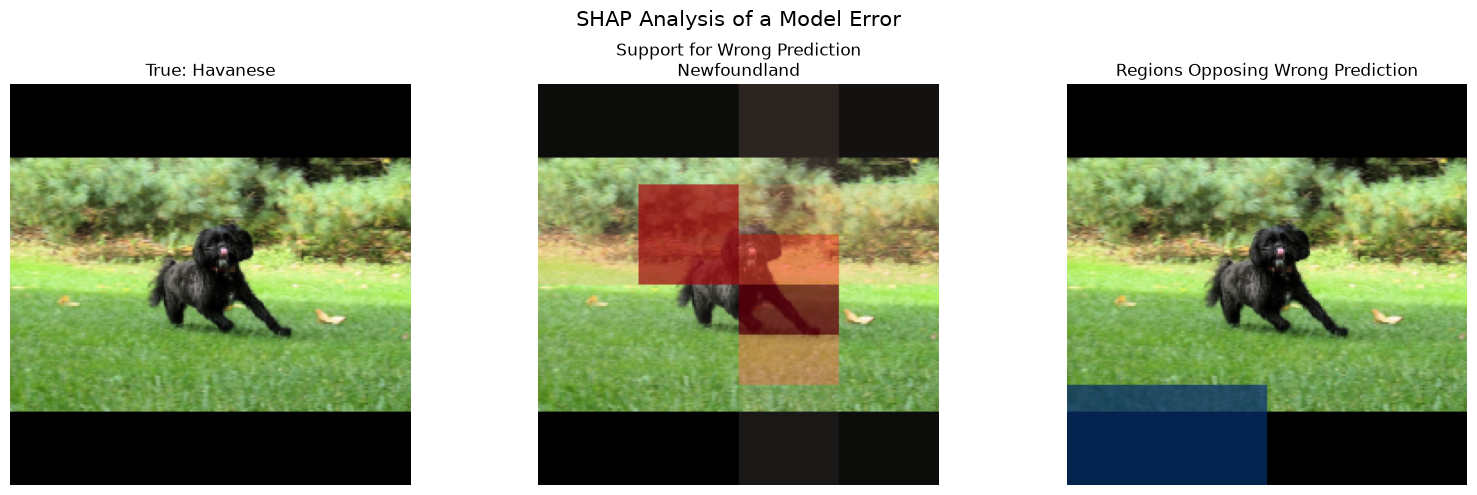

In [15]:
print(
    "Calculating SHAP for the wrong prediction..."
)

wrong_shap_values = image_explainer(
    wrong_model_image,
    max_evals=100,
    batch_size=10,
    outputs=shap.Explanation.argsort.flip[:1],
)

wrong_values = wrong_shap_values.values[0]

if wrong_values.ndim == 4:
    wrong_values = wrong_values[..., 0]

wrong_signed_importance = (
    wrong_values.sum(axis=-1)
)

wrong_positive_support = np.maximum(
    wrong_signed_importance,
    0,
)

wrong_negative_support = np.maximum(
    -wrong_signed_importance,
    0,
)

positive_limit = max(
    np.percentile(
        wrong_positive_support,
        99,
    ),
    1e-8,
)

negative_limit = max(
    np.percentile(
        wrong_negative_support,
        99,
    ),
    1e-8,
)

wrong_model_display = np.clip(
    (wrong_model_image[0] + 1.0) / 2.0,
    0,
    1,
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(wrong_model_display)
axes[0].set_title(
    "True: "
    + display_class_names[wrong_true_index]
)
axes[0].axis("off")

axes[1].imshow(wrong_model_display)
axes[1].imshow(
    wrong_positive_support,
    cmap="Reds",
    alpha=np.clip(
        wrong_positive_support /
        positive_limit,
        0,
        0.75,
    ),
)
axes[1].set_title(
    "Support for Wrong Prediction\n"
    + display_class_names[
        wrong_predicted_index
    ]
)
axes[1].axis("off")

axes[2].imshow(wrong_model_display)
axes[2].imshow(
    wrong_negative_support,
    cmap="Blues",
    alpha=np.clip(
        wrong_negative_support /
        negative_limit,
        0,
        0.75,
    ),
)
axes[2].set_title(
    "Regions Opposing Wrong Prediction"
)
axes[2].axis("off")

plt.suptitle(
    "SHAP Analysis of a Model Error",
    fontsize=15,
)
plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "wrong_prediction_shap.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

<h2 style="color:#0072B2;">5.11 Global SHAP Importance</h2>

A local explanation describes one prediction. A global explanation summarizes
patterns across several images.

Five correctly classified images from different breeds are selected. Their absolute
SHAP values are averaged to measure which spatial regions generally have the largest
effect on model decisions.

Absolute values are used because global importance measures the strength of an
effect, regardless of whether it pushes a particular class probability upward or
downward.

In [16]:
global_example_positions = []
selected_prediction_classes = set()

sorted_correct_positions = np.where(
    correct_prediction_mask
)[0][
    np.argsort(
        prediction_confidence[
            correct_prediction_mask
        ]
    )[::-1]
]

for position in sorted_correct_positions:
    predicted_class = int(
        model_predictions[position]
    )

    if predicted_class in selected_prediction_classes:
        continue

    global_example_positions.append(
        int(position)
    )
    selected_prediction_classes.add(
        predicted_class
    )

    if len(global_example_positions) == 5:
        break

global_model_images = np.stack([
    preprocess_pet_image(
        test_metadata.loc[
            position,
            "image_path",
        ]
    )
    for position in global_example_positions
])

global_selection_table = pd.DataFrame({
    "test_position": global_example_positions,
    "breed": [
        display_class_names[
            model_predictions[position]
        ]
        for position in global_example_positions
    ],
    "confidence": [
        prediction_confidence[position]
        for position in global_example_positions
    ],
})

display(
    global_selection_table.round(4)
)

print(
    "Calculating Global SHAP using",
    len(global_model_images),
    "images...",
)

global_shap_values = image_explainer(
    global_model_images,
    max_evals=100,
    batch_size=10,
    outputs=shap.Explanation.argsort.flip[:1],
)

print(
    "Global SHAP shape:",
    global_shap_values.values.shape,
)

,test_position,breed,confidence
0,588,Wheaten Terrier,1.0000
1,864,Pug,1.0000
2,653,Egyptian Mau,1.0000
3,1080,Shiba Inu,0.9999
4,1035,Sphynx,0.9999


Calculating Global SHAP using 5 images...


PartitionExplainer explainer: 6it [00:20,  6.79s/it]                       

Global SHAP shape: (5, 224, 224, 3, 1)


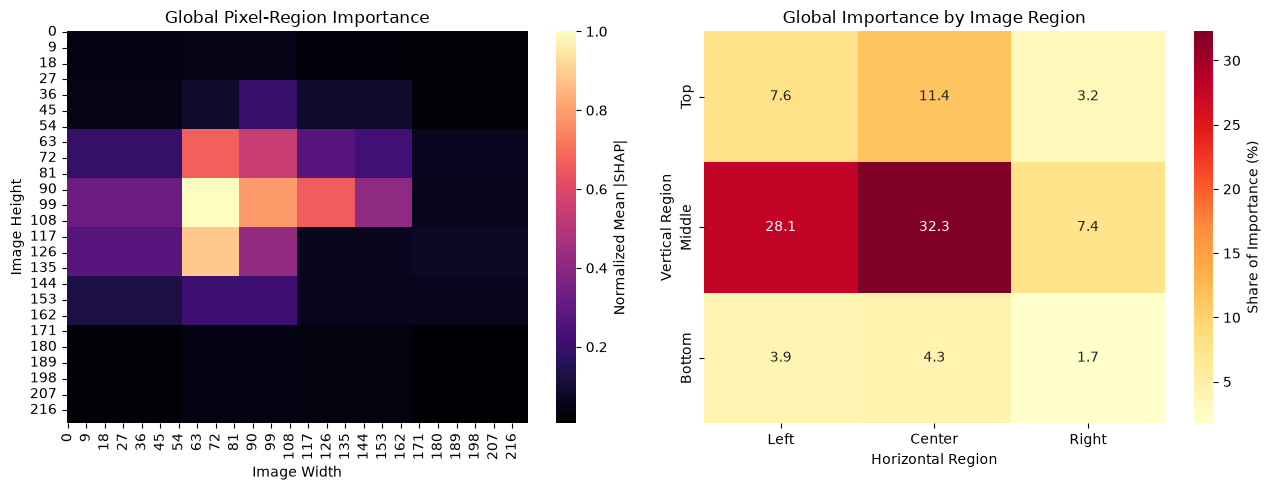

,Left,Center,Right
Top,7.61,11.44,3.19
Middle,28.08,32.27,7.41
Bottom,3.92,4.34,1.75


In [17]:
global_values = global_shap_values.values

if global_values.ndim == 5:
    global_values = global_values[..., 0]

global_importance_map = np.mean(
    np.abs(global_values),
    axis=(0, 3),
)

importance_limit = max(
    np.percentile(
        global_importance_map,
        99,
    ),
    1e-8,
)

normalized_global_importance = np.clip(
    global_importance_map /
    importance_limit,
    0,
    1,
)

grid_size = 3
height_step = TARGET_SIZE[1] // grid_size
width_step = TARGET_SIZE[0] // grid_size

grid_importance = np.zeros(
    (grid_size, grid_size)
)

for row in range(grid_size):
    for column in range(grid_size):
        row_start = row * height_step
        row_end = (
            TARGET_SIZE[1]
            if row == grid_size - 1
            else (row + 1) * height_step
        )

        column_start = column * width_step
        column_end = (
            TARGET_SIZE[0]
            if column == grid_size - 1
            else (column + 1) * width_step
        )

        grid_importance[row, column] = (
            global_importance_map[
                row_start:row_end,
                column_start:column_end,
            ].mean()
        )

grid_importance_percentage = (
    100 * grid_importance /
    grid_importance.sum()
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

sns.heatmap(
    normalized_global_importance,
    cmap="magma",
    ax=axes[0],
    cbar_kws={
        "label": "Normalized Mean |SHAP|"
    },
)

axes[0].set_title(
    "Global Pixel-Region Importance"
)
axes[0].set_xlabel("Image Width")
axes[0].set_ylabel("Image Height")

sns.heatmap(
    grid_importance_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=axes[1],
    xticklabels=["Left", "Center", "Right"],
    yticklabels=["Top", "Middle", "Bottom"],
    cbar_kws={
        "label": "Share of Importance (%)"
    },
)

axes[1].set_title(
    "Global Importance by Image Region"
)
axes[1].set_xlabel("Horizontal Region")
axes[1].set_ylabel("Vertical Region")

plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "global_shap_importance.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

global_region_table = pd.DataFrame(
    grid_importance_percentage,
    index=["Top", "Middle", "Bottom"],
    columns=["Left", "Center", "Right"],
)

display(
    global_region_table.round(2)
)

global_region_table.to_csv(
    DAY5_OUTPUT_DIRECTORY /
    "global_shap_regions.csv"
)

<h2 style="color:#0072B2;">5.12 SHAP Findings</h2>

### Correct Prediction

The Sphynx image was classified correctly with 97.95% confidence.

Positive SHAP support appeared around the large ears, wrinkled face, exposed skin,
and front limbs. These are meaningful characteristics of the Sphynx breed.

### Incorrect Prediction

A Havanese image was incorrectly classified as Newfoundland with 99.05% confidence.

The image was clear and the strongest positive regions overlapped the dog's dark
coat and body. Havanese and Newfoundland dogs can share long, dark fur, but they
differ strongly in body size.

The model sees visual appearance without directly understanding real-world physical
size. Therefore, this error is categorized as a **model weakness caused by visual
similarity**, rather than a data-quality issue.

Some supporting regions also extended into the surrounding grass, indicating that
background context may have slightly influenced the prediction.

### Global Explanation

The five-image Global SHAP analysis showed:

- Middle row: **67.76%** of total spatial importance.
- Middle-left region: **28.08%**.
- Middle-center region: **32.27%**.
- Middle-left and middle-center combined: **60.35%**.
- Bottom row: only **10.01%**.

This indicates that the model usually concentrated on the central animal regions
and assigned less importance to padding and outer background areas.

Because Global SHAP used five high-confidence images to keep CPU execution practical,
it should be interpreted as a representative explanation rather than an exact
summary of all 1,109 test images.

<h2 style="color:#0072B2;">5.13 Communicating Results to Non-Technical Stakeholders</h2>

The system can distinguish between 37 cat and dog breeds.

On completely unseen test images, it selected the correct breed approximately
89 times out of every 100 images. The correct breed appeared among its three strongest
suggestions approximately 98 times out of every 100 images.

The model performs much better than a baseline that does not inspect the image,
which achieved only 2.71% accuracy.

The explanations show that the model generally focuses on meaningful animal regions,
such as the face, ears, fur, and body. However, visually similar breeds can still be
confused with high confidence.

For deployment, the user should see the three strongest predictions and their
probabilities rather than receiving one breed name without context.

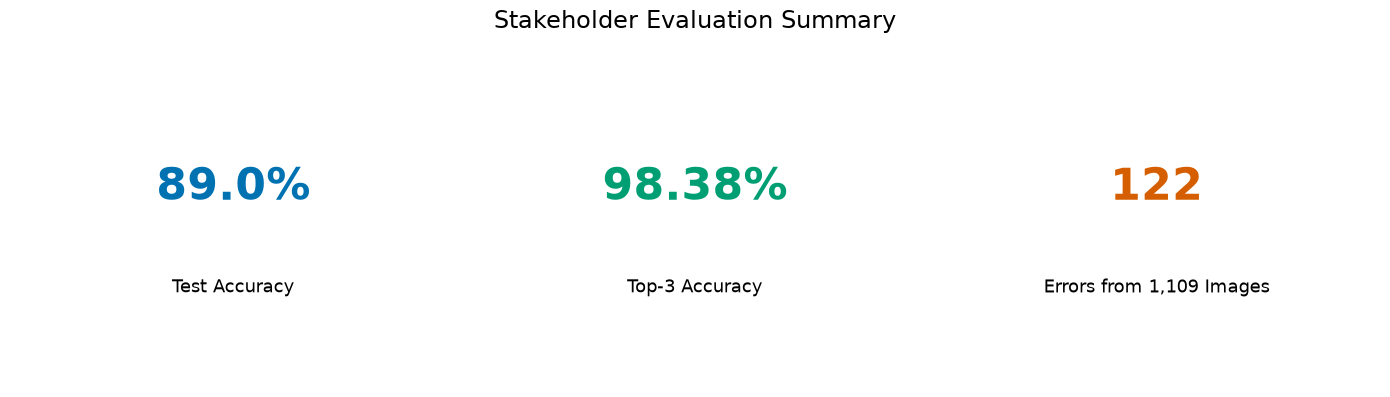

In [18]:
model_result = (
    complete_evaluation[
        complete_evaluation["model"]
        == "MobileNetV2 Classifier"
    ]
    .iloc[0]
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
)

dashboard_values = [
    (
        f"{100 * model_result['accuracy']:.1f}%",
        "Test Accuracy",
        "#0072B2",
    ),
    (
        f"{100 * model_result['top_3_accuracy']:.2f}%",
        "Top-3 Accuracy",
        "#009E73",
    ),
    (
        str(
            int(
                np.sum(
                    model_predictions
                    != true_labels
                )
            )
        ),
        "Errors from 1,109 Images",
        "#D55E00",
    ),
]

for axis, (
    value,
    label,
    color,
) in zip(axes, dashboard_values):
    axis.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=32,
        fontweight="bold",
        color=color,
    )

    axis.text(
        0.5,
        0.30,
        label,
        ha="center",
        va="center",
        fontsize=13,
    )

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.axis("off")

plt.suptitle(
    "Stakeholder Evaluation Summary",
    fontsize=17,
)
plt.tight_layout()

plt.savefig(
    DAY5_OUTPUT_DIRECTORY /
    "stakeholder_summary.png",
    dpi=170,
    bbox_inches="tight",
)

plt.show()

<h2 style="color:#0072B2;">5.14 Sprint Review</h2>

## Completed Work

- Created a consistent OpenCV preprocessing pipeline.
- Preserved aspect ratio using resizing and padding.
- Applied MobileNetV2-compatible normalization.
- Trained a 37-class transfer-learning classifier.
- Integrated raw image preprocessing and prediction.
- Evaluated the system on an unseen test set.
- Compared the classifier against a valid class-prior baseline.
- Reported accuracy, precision, recall, F1, Top-3 accuracy, ROC-AUC, and PR-AUC.
- Verified that SMOTE was unnecessary and unsuitable for this balanced image task.
- Identified weak breeds using per-class metrics and Precision–Recall curves.
- Analyzed systematic errors using the confusion matrix.
- Generated SHAP explanations for correct and incorrect predictions.
- Generated a representative Global SHAP spatial-importance map.
- Exported the trained model and preprocessing contract for deployment.

## Acceptance Criteria

| Criterion | Result |
|---|---|
| End-to-end prediction pipeline | Passed |
| Training/serving consistency | Passed |
| Full evaluation against baseline | Passed |
| Imbalance decision documented | Passed |
| Global SHAP explanation | Passed |
| Individual SHAP explanation | Passed |
| Misclassified examples analyzed | Passed |
| Deployment artifacts exported | Passed |

The internship repository uses direct commits and pushes. Therefore, the completed
notebook and generated results should be committed to the correct Week 8 Day 5
directory without claiming an unperformed pull-request approval.

<h2 style="color:#0072B2;">5.15 Sprint Retrospective</h2>

## What Went Well

- Transfer learning produced strong results without training a large CNN from scratch.
- The validation and test results remained close, indicating good generalization.
- Top-3 accuracy reached 98.38%.
- SHAP confirmed that important animal regions generally influenced predictions.
- The exported preprocessing configuration makes future deployment reproducible.

## What Was Difficult

- Several breeds have very similar coats, faces, and body structures.
- American Pit Bull Terrier and Staffordshire Bull Terrier were frequently confused.
- The model sometimes produced very high confidence for an incorrect breed.
- SHAP image explanations required considerably more computation than normal predictions.
- A small representative sample was required for Global SHAP because execution used CPU.

## Concrete Change for Sprint 4

Sprint 4 will implement a confidence-aware web interface.

For every uploaded image, the interface will display:

- The three strongest breed predictions.
- The probability of every displayed prediction.
- A visual explanation of the influential image regions.
- A warning when the prediction is uncertain.

This change will make the trained model understandable and usable rather than exposing
only a raw class number.

In [20]:
day5_result_summary = {
    "task": "Oxford-IIIT Pet 37-breed classification",
    "test_images": int(len(true_labels)),
    "number_of_classes": int(number_of_classes),
    "baseline_accuracy": float(
        complete_evaluation.loc[
            complete_evaluation["model"]

            == "Class-Prior Baseline",
            "accuracy",
        ].iloc[0]
    ),
    "model_accuracy": float(
        model_result["accuracy"]
    ),
    "top_3_accuracy": float(
        model_result["top_3_accuracy"]
    ),
    "macro_f1": float(
        model_result["macro_f1"]
    ),
    "macro_roc_auc_ovr": float(
        model_result["roc_auc_macro_ovr"]
    ),
    "macro_pr_auc": float(
        model_result["pr_auc_macro"]
    ),
    "correct_predictions": int(
        np.sum(
            model_predictions == true_labels
        )
    ),
    "incorrect_predictions": int(
        np.sum(
            model_predictions != true_labels
        )
    ),
    "local_shap_completed": True,
    "wrong_prediction_shap_completed": True,
    "global_shap_images": int(
        len(global_example_positions)
    ),
}

SUMMARY_PATH = (
    DAY5_OUTPUT_DIRECTORY /
    "day5_result_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        day5_result_summary,
        summary_file,
        indent=2,
    )

required_outputs = [
    "baseline_comparison.csv",
    "baseline_comparison.png",
    "per_breed_metrics.csv",
    "weakest_breeds_precision_recall.png",
    "local_shap_explanation.png",
    "wrong_prediction_shap.png",
    "global_shap_importance.png",
    "global_shap_regions.csv",
    "stakeholder_summary.png",
    "day5_result_summary.json",
]

output_check = pd.DataFrame({
    "output": required_outputs,
    "created": [
        (
            DAY5_OUTPUT_DIRECTORY /
            filename
        ).exists()
        for filename in required_outputs
    ],
})

display(output_check)

assert output_check["created"].all()
assert model_result["accuracy"] > 0.85
assert model_result["top_3_accuracy"] > 0.95
assert np.isclose(
    grid_importance_percentage.sum(),
    100.0,
)

print("All Day 5 quality checks passed.")
print("Results directory:", DAY5_OUTPUT_DIRECTORY)

,output,created
0,baseline_comparison.csv,True
1,baseline_comparison.png,True
2,per_breed_metrics.csv,True
3,weakest_breeds_precision_recall.png,True
4,local_shap_explanation.png,True
5,wrong_prediction_shap.png,True
6,global_shap_importance.png,True
7,global_shap_regions.csv,True
8,stakeholder_summary.png,True
9,day5_result_summary.json,True


All Day 5 quality checks passed.
Results directory: outputs/week8_day5


<h2 style="color:#0072B2;">Day 5 Conclusion</h2>

The complete Sprint 3 image-classification system achieved 89.00% test accuracy and
98.38% Top-3 accuracy across 37 pet breeds.

The model substantially outperformed the task baseline, while per-class evaluation
identified specific weaknesses between visually similar breeds.

SHAP explanations connected the mathematical model output with visible image regions,
showing why correct and incorrect predictions were produced.

The sprint now closes with a trained, evaluated, explainable, and exported model.
The next sprint will focus on web deployment, user interaction, confidence
communication, and final presentation polish.